In [4]:
# Install openpyxl to read .xlsx files
!pip install openpyxl -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries ready")

✅ Libraries ready


In [11]:
# Load the dataset
df = pd.read_excel('/content/EcommerceWB.xlsx', sheet_name='ecommerce_10000')

In [12]:
if df['OrderDate'].dtype in ['int64', 'float64']:
    df['OrderDate'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(df['OrderDate'], unit='D')
else:
    df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create date columns
df['Year']      = df['OrderDate'].dt.year
df['Month']     = df['OrderDate'].dt.month
df['Quarter']   = df['OrderDate'].dt.quarter
df['DayOfWeek'] = df['OrderDate'].dt.day_name()

print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 16)


,OrderID,Product,Category,Brand,Platform,City,Price,Quantity,TotalAmount,Rating,Reviews,OrderDate,Year,Month,Quarter,DayOfWeek
0,ORD100000,Samsung Galaxy A14,Electronics,Samsung,Souq,Cairo,16284.02,1,16284.02,1.39,1684,2024-11-11,2024,11,4,Monday
1,ORD100001,Nike Air Max,Fashion,Nike,Jumia,Alexandria,6645.20,2,13290.40,2.56,3604,2024-06-22,2024,6,2,Saturday
2,ORD100002,Bluetooth Headset,Accessories,JBL,Jumia,Casablanca,8882.92,3,26648.76,4.98,1257,2024-05-27,2024,5,2,Monday
3,ORD100003,HP Pavilion Laptop,Computers,HP,Souq,Dubai,3665.44,1,3665.44,1.44,662,2024-07-25,2024,7,3,Thursday
4,ORD100004,iPhone 13,Electronics,Apple,Souq,Casablanca,5210.37,2,10420.74,3.73,2424,2024-02-19,2024,2,1,Monday


In [14]:
# Check column types and missing values
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== DATA TYPES ===
OrderID                object
Product                object
Category               object
Brand                  object
Platform               object
City                   object
Price                 float64
Quantity                int64
TotalAmount           float64
Rating                float64
Reviews                 int64
OrderDate      datetime64[ns]
Year                    int32
Month                   int32
Quarter                 int32
DayOfWeek              object
dtype: object

=== NULL VALUES ===
OrderID        0
Product        0
Category       0
Brand          0
Platform       0
City           0
Price          0
Quantity       0
TotalAmount    0
Rating         0
Reviews        0
OrderDate      0
Year           0
Month          0
Quarter        0
DayOfWeek      0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0


In [15]:
# Summary stats for all numeric columns
df[['Price','Quantity','TotalAmount','Rating','Reviews']].describe().round(2)

,Price,Quantity,TotalAmount,Rating,Reviews
count,10000.00,10000.00,10000.00,10000.00,10000.00
mean,10027.99,3.01,30199.57,3.01,2520.07
std,5728.26,1.42,23861.79,1.15,1443.85
min,105.59,1.00,113.55,1.00,0.00
25%,4999.86,2.00,11066.91,2.01,1275.00
50%,10063.60,3.00,23671.63,3.00,2537.50
75%,14938.43,4.00,44648.58,4.00,3767.00
max,19999.34,5.00,99993.80,5.00,5000.00


In [16]:
# How many unique values each category has
cat_cols = ['Product','Category','Brand','Platform','City']
for col in cat_cols:
    print(f"{col:12}: {df[col].nunique()} unique → {sorted(df[col].unique())}")

Product     : 10 unique → ['Adidas Running Shoes', 'Bluetooth Headset', 'Dell Inspiron 3501', 'HP Pavilion Laptop', 'Nike Air Max', 'Samsung Galaxy A14', 'Smartwatch FitPro', 'T-shirt Cotton', 'Xiaomi Redmi Note 12', 'iPhone 13']
Category    : 5 unique → ['Accessories', 'Computers', 'Electronics', 'Fashion', 'Wearables']
Brand       : 10 unique → ['Adidas', 'Apple', 'Dell', 'FitPro', 'Generic', 'HP', 'JBL', 'Nike', 'Samsung', 'Xiaomi']
Platform    : 3 unique → ['Amazon', 'Jumia', 'Souq']
City        : 6 unique → ['Alexandria', 'Cairo', 'Casablanca', 'Dubai', 'Giza', 'Riyadh']


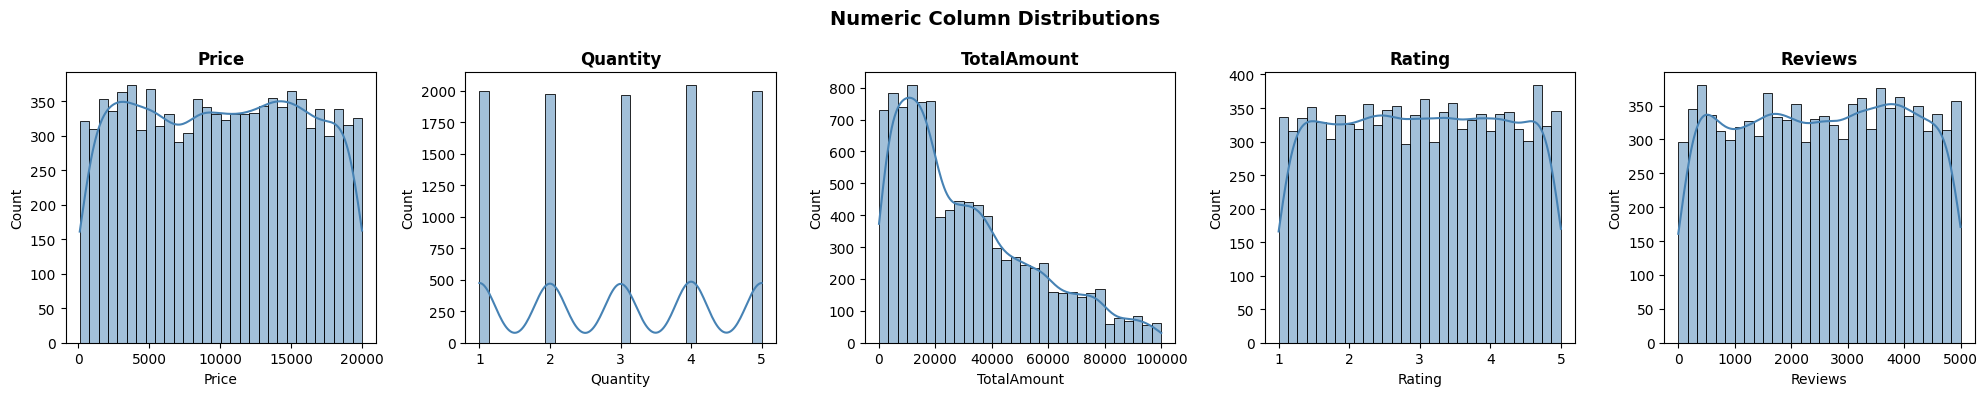

In [17]:
# Histogram + KDE for each numeric column
num_cols = ['Price','Quantity','TotalAmount','Rating','Reviews']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')

plt.suptitle('Numeric Column Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

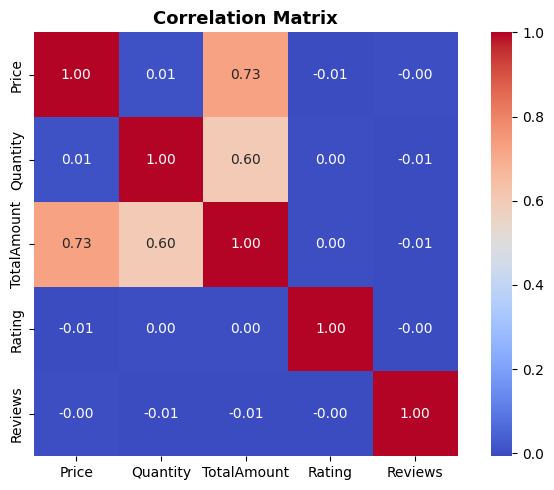

In [18]:
# Shows how numeric columns relate to each other
corr = df[['Price','Quantity','TotalAmount','Rating','Reviews']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Key business metrics at a glance
kpis = {
    'Total Orders'    : len(df),
    'Total Revenue'   : df['TotalAmount'].sum(),
    'Avg Order Value' : df['TotalAmount'].mean(),
    'Total Units Sold': df['Quantity'].sum(),
    'Avg Rating'      : df['Rating'].mean(),
    'Total Reviews'   : df['Reviews'].sum(),
}

print("📊 KPI SUMMARY")
print("─" * 40)
for k, v in kpis.items():
    print(f"  {k:<22}: {v:,.2f}")

📊 KPI SUMMARY
────────────────────────────────────────
  Total Orders          : 10,000.00
  Total Revenue         : 301,995,724.39
  Avg Order Value       : 30,199.57
  Total Units Sold      : 30,062.00
  Avg Rating            : 3.01
  Total Reviews         : 25,200,722.00


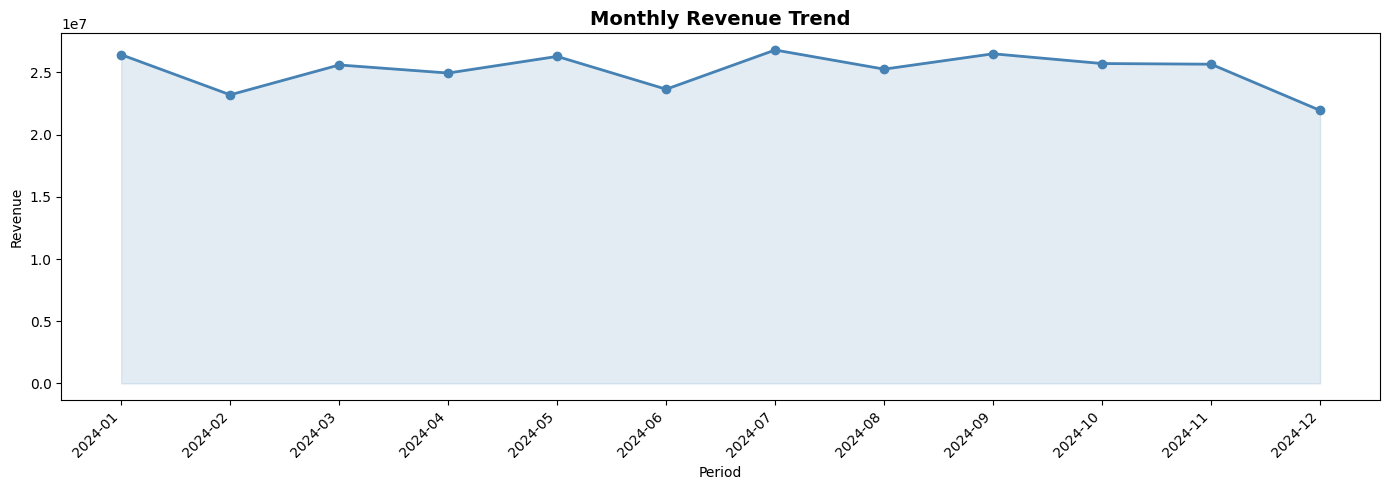

In [20]:
# Group revenue by Year + Month
monthly = (df.groupby(['Year','Month'])['TotalAmount']
             .sum()
             .reset_index()
             .sort_values(['Year','Month']))

monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

# Line chart
plt.figure(figsize=(14, 5))
plt.plot(monthly['Period'], monthly['TotalAmount'], marker='o', linewidth=2, color='steelblue')
plt.fill_between(monthly['Period'], monthly['TotalAmount'], alpha=0.15, color='steelblue')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Period')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

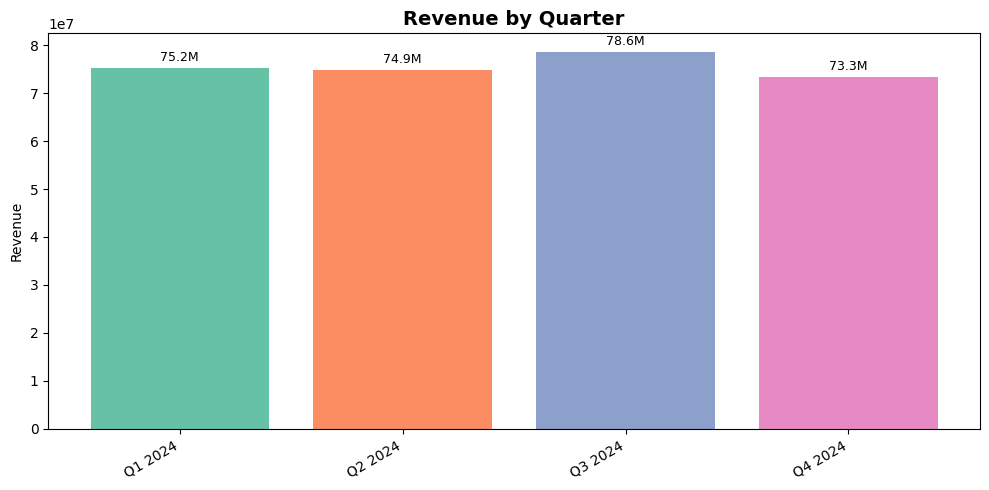

In [21]:
# Compare performance across quarters
quarterly = df.groupby(['Year','Quarter'])['TotalAmount'].sum().reset_index()
quarterly['QLabel'] = 'Q' + quarterly['Quarter'].astype(str) + ' ' + quarterly['Year'].astype(str)

plt.figure(figsize=(10, 5))
bars = plt.bar(quarterly['QLabel'], quarterly['TotalAmount'],
               color=sns.color_palette('Set2', len(quarterly)))
plt.bar_label(bars, fmt=lambda x: f'{x/1e6:.1f}M', padding=3, fontsize=9)
plt.title('Revenue by Quarter', fontsize=14, fontweight='bold')
plt.ylabel('Revenue')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

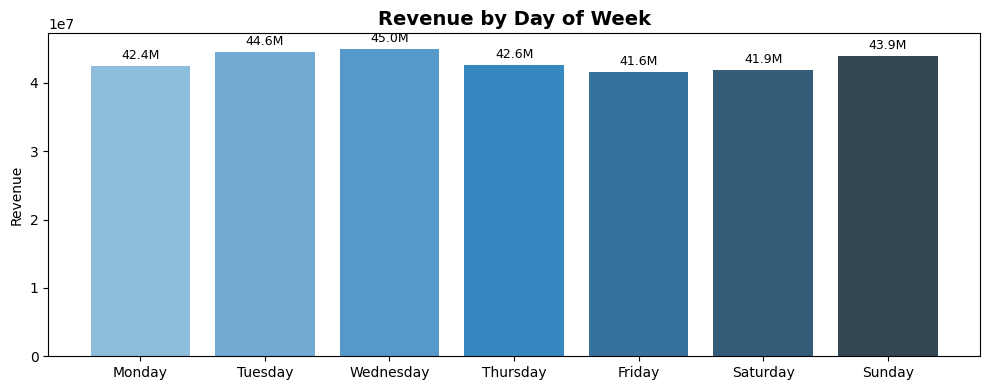

In [22]:
# Which day generates the most sales?
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('DayOfWeek')['TotalAmount'].sum().reindex(dow_order)

plt.figure(figsize=(10, 4))
bars = plt.bar(dow.index, dow.values, color=sns.color_palette('Blues_d', 7))
plt.bar_label(bars, fmt=lambda x: f'{x/1e6:.1f}M', padding=3, fontsize=9)
plt.title('Revenue by Day of Week', fontsize=14, fontweight='bold')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

In [23]:
# Year-over-year revenue summary
yearly = df.groupby('Year').agg(
    Revenue = ('TotalAmount','sum'),
    Orders  = ('OrderID','count'),
    AvgOrder= ('TotalAmount','mean')
).round(2)

print("📅 YEARLY SUMMARY")
print(yearly)

📅 YEARLY SUMMARY
           Revenue  Orders  AvgOrder
Year                                
2024  3.019957e+08   10000  30199.57


In [24]:
# Summary table: revenue, orders, avg rating per category
cat_summary = df.groupby('Category').agg(
    Revenue   = ('TotalAmount','sum'),
    Orders    = ('OrderID','count'),
    AvgRating = ('Rating','mean'),
    AvgPrice  = ('Price','mean')
).sort_values('Revenue', ascending=False).round(2)

print("📦 CATEGORY SUMMARY")
print(cat_summary)

📦 CATEGORY SUMMARY
                 Revenue  Orders  AvgRating  AvgPrice
Category                                             
Electronics  92327183.77    3028       3.03  10139.97
Fashion      91504159.73    2970       2.96  10160.24
Computers    57542997.56    1953       3.03   9801.99
Wearables    31420413.20    1020       3.03  10064.10
Accessories  29200970.13    1029       3.00   9709.87


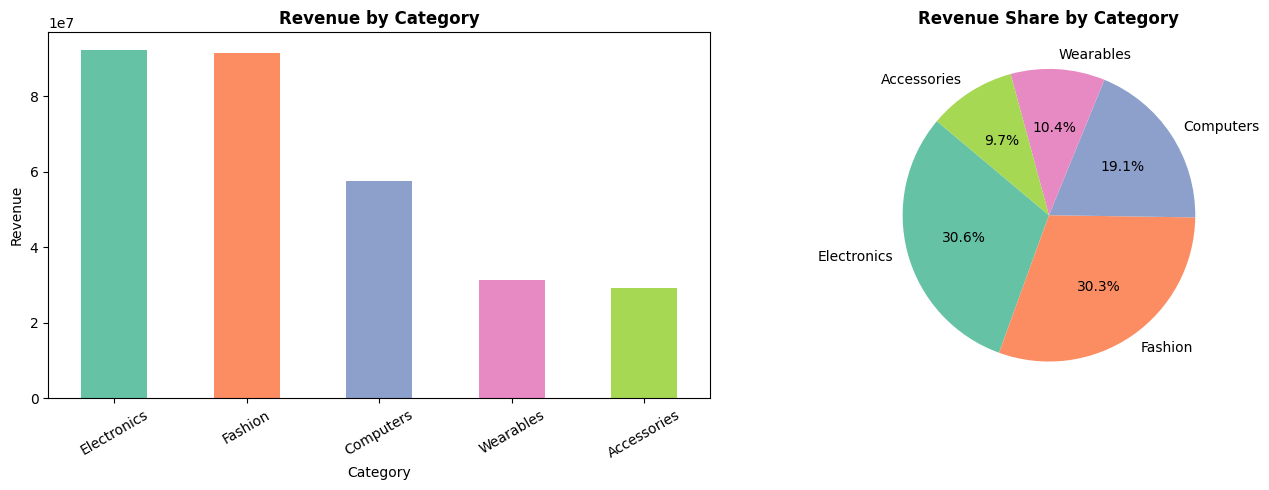

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
cat_summary['Revenue'].plot(kind='bar', ax=axes[0],
                             color=sns.color_palette('Set2', len(cat_summary)))
axes[0].set_title('Revenue by Category', fontweight='bold')
axes[0].set_ylabel('Revenue')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(cat_summary['Revenue'], labels=cat_summary.index,
            autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(cat_summary)),
            startangle=140)
axes[1].set_title('Revenue Share by Category', fontweight='bold')

plt.tight_layout()
plt.show()

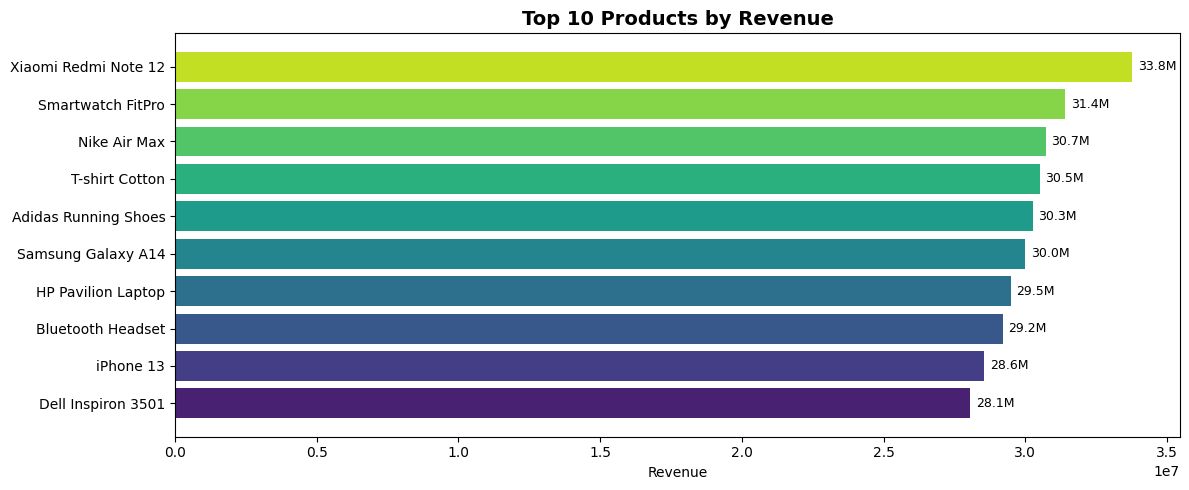

In [26]:
# Top 10 products ranked by total revenue
top_products = (df.groupby('Product')['TotalAmount']
                  .sum()
                  .sort_values(ascending=True)
                  .tail(10))

plt.figure(figsize=(12, 5))
bars = plt.barh(top_products.index, top_products.values,
                color=sns.color_palette('viridis', 10))
plt.bar_label(bars, fmt=lambda x: f'{x/1e6:.1f}M', padding=4, fontsize=9)
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

🏷️ BRAND SUMMARY
             Revenue  Orders  AvgPrice  AvgRating
Brand                                            
Xiaomi   33772598.37    1030  10421.68       2.99
FitPro   31420413.20    1020  10064.10       3.03
Nike     30727637.51    1005  10107.31       2.96
Generic  30507500.40     997  10029.69       2.95
Adidas   30269021.82     968  10349.65       2.97
Samsung  30004263.23    1043   9885.62       3.05
HP       29482727.14     991  10012.15       3.07
JBL      29200970.13    1029   9709.87       3.00
Apple    28550322.17     955  10113.94       3.06
Dell     28060270.42     962   9585.49       2.99


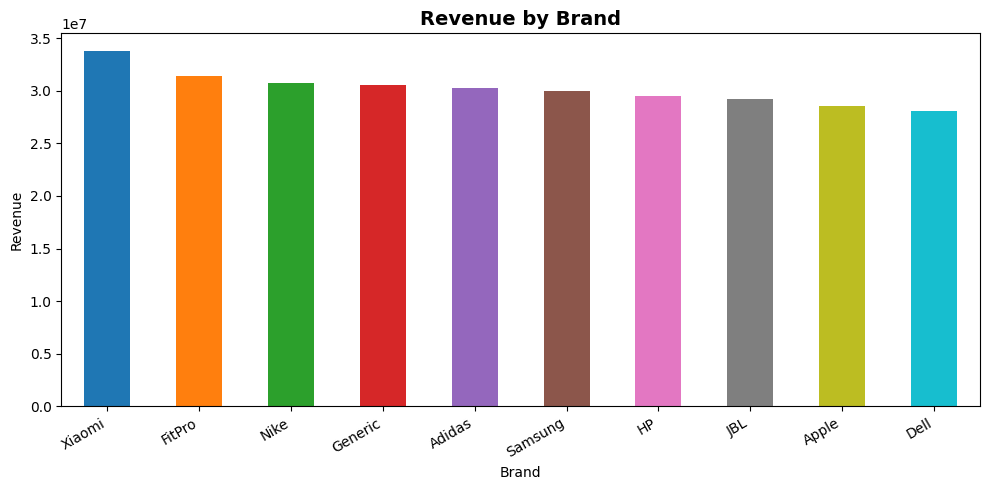

In [27]:
# Revenue, orders, avg price and rating per brand
brand_summary = df.groupby('Brand').agg(
    Revenue   = ('TotalAmount','sum'),
    Orders    = ('OrderID','count'),
    AvgPrice  = ('Price','mean'),
    AvgRating = ('Rating','mean')
).sort_values('Revenue', ascending=False).round(2)

print("🏷️ BRAND SUMMARY")
print(brand_summary)

# Bar chart
brand_summary['Revenue'].plot(kind='bar', figsize=(10, 5),
                               color=sns.color_palette('tab10', len(brand_summary)))
plt.title('Revenue by Brand', fontsize=14, fontweight='bold')
plt.ylabel('Revenue')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [28]:
# Which brand dominates which category?
pivot_brand = df.pivot_table(
    values='TotalAmount',
    index='Brand',
    columns='Category',
    aggfunc='sum',
    fill_value=0
).round(0)

print("📊 Brand × Category Revenue Pivot")
print(pivot_brand)

📊 Brand × Category Revenue Pivot
Category  Accessories   Computers  Electronics     Fashion   Wearables
Brand                                                                 
Adidas            0.0         0.0          0.0  30269022.0         0.0
Apple             0.0         0.0   28550322.0         0.0         0.0
Dell              0.0  28060270.0          0.0         0.0         0.0
FitPro            0.0         0.0          0.0         0.0  31420413.0
Generic           0.0         0.0          0.0  30507500.0         0.0
HP                0.0  29482727.0          0.0         0.0         0.0
JBL        29200970.0         0.0          0.0         0.0         0.0
Nike              0.0         0.0          0.0  30727638.0         0.0
Samsung           0.0         0.0   30004263.0         0.0         0.0
Xiaomi            0.0         0.0   33772598.0         0.0         0.0


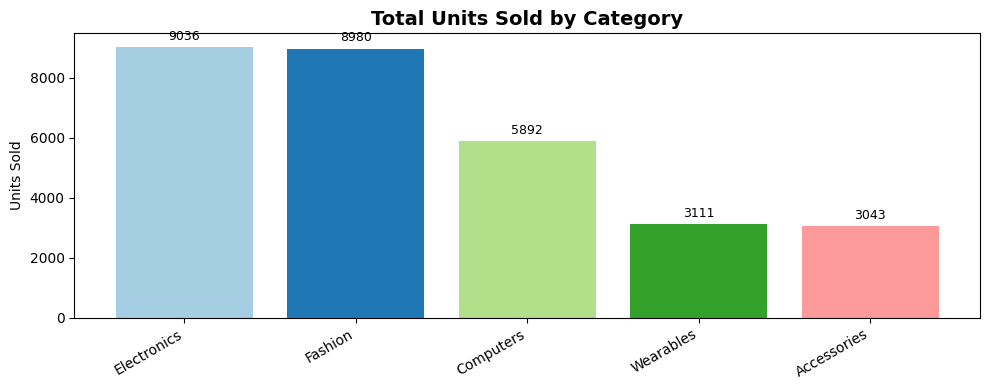

In [29]:
# Quantity sold per category — not just revenue
units = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
bars = plt.bar(units.index, units.values,
               color=sns.color_palette('Paired', len(units)))
plt.bar_label(bars, padding=3, fontsize=9)
plt.title('Total Units Sold by Category', fontsize=14, fontweight='bold')
plt.ylabel('Units Sold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [30]:
# Revenue, orders, avg order value and rating per platform
platform_summary = df.groupby('Platform').agg(
    Revenue   = ('TotalAmount','sum'),
    Orders    = ('OrderID','count'),
    AvgOrder  = ('TotalAmount','mean'),
    AvgRating = ('Rating','mean')
).sort_values('Revenue', ascending=False).round(2)

print("🛒 PLATFORM SUMMARY")
print(platform_summary)

🛒 PLATFORM SUMMARY
               Revenue  Orders  AvgOrder  AvgRating
Platform                                           
Souq      1.019210e+08    3371  30234.64       3.01
Jumia     1.016971e+08    3341  30439.11       3.00
Amazon    9.837767e+07    3288  29920.22       3.01


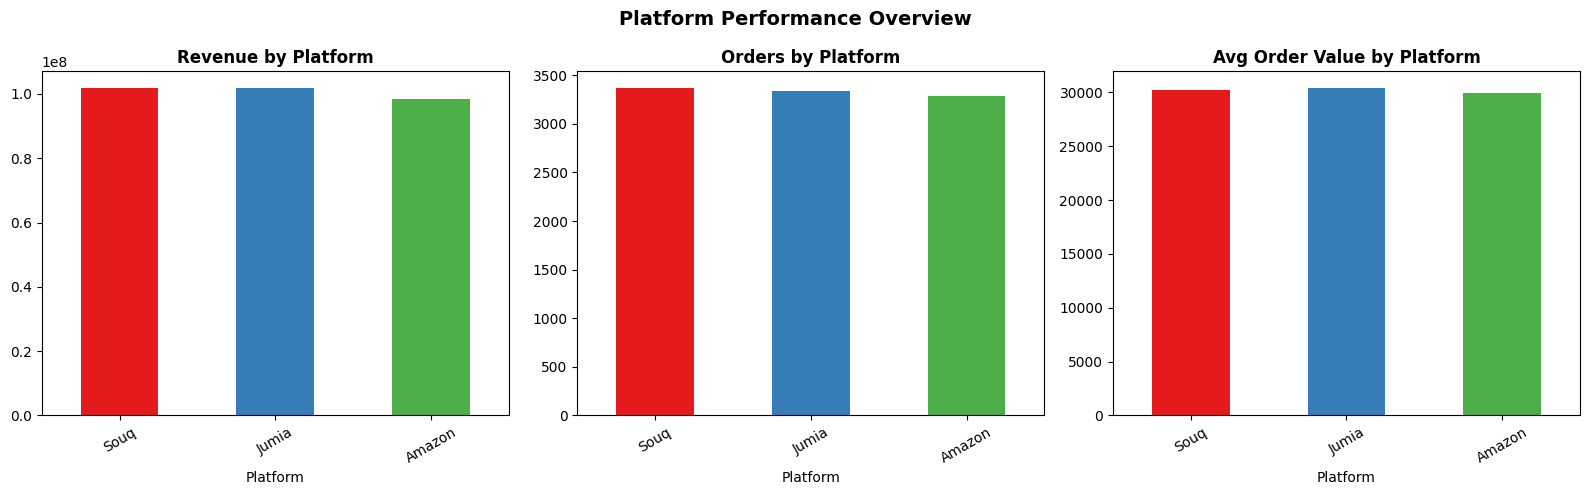

In [31]:
# Side by side bar charts for Revenue, Orders, Avg Order Value
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Revenue', 'Orders', 'AvgOrder']
titles  = ['Revenue by Platform', 'Orders by Platform', 'Avg Order Value by Platform']
colors  = sns.color_palette('Set1', len(platform_summary))

for ax, metric, title in zip(axes, metrics, titles):
    platform_summary[metric].plot(kind='bar', ax=ax, color=colors)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Platform Performance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

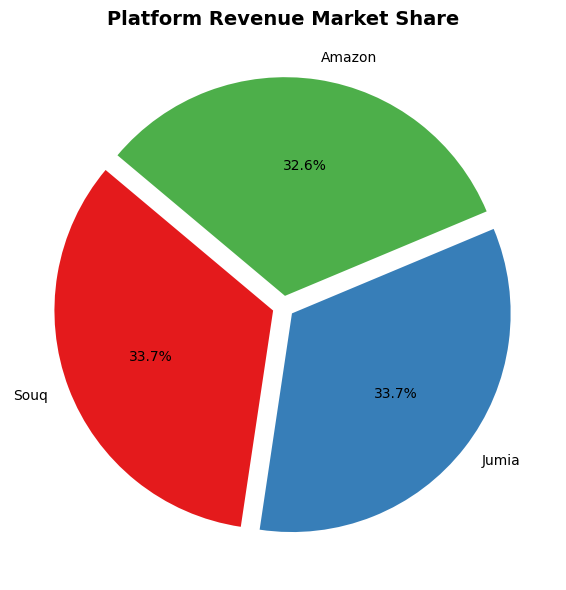

In [32]:
# Revenue share across platforms
plt.figure(figsize=(7, 6))
plt.pie(platform_summary['Revenue'],
        labels=platform_summary.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('Set1', len(platform_summary)),
        startangle=140,
        explode=[0.05] * len(platform_summary))
plt.title('Platform Revenue Market Share', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

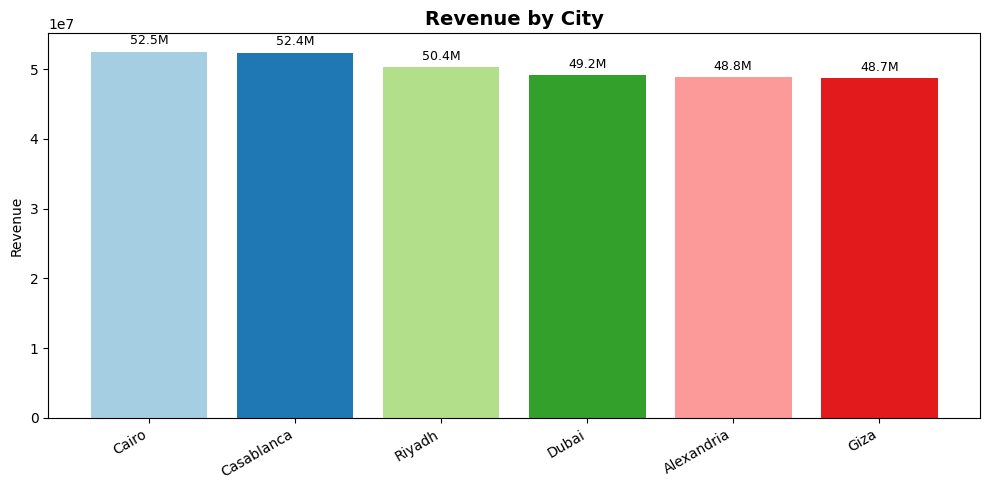

In [33]:
# Total revenue per city
city_rev = df.groupby('City')['TotalAmount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(city_rev.index, city_rev.values,
               color=sns.color_palette('Paired', len(city_rev)))
plt.bar_label(bars, fmt=lambda x: f'{x/1e6:.1f}M', padding=3, fontsize=9)
plt.title('Revenue by City', fontsize=14, fontweight='bold')
plt.ylabel('Revenue')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [34]:
# Full city breakdown
city_summary = df.groupby('City').agg(
    Revenue   = ('TotalAmount','sum'),
    Orders    = ('OrderID','count'),
    AvgOrder  = ('TotalAmount','mean'),
    AvgRating = ('Rating','mean')
).sort_values('Revenue', ascending=False).round(2)

print("🏙️ CITY SUMMARY")
print(city_summary)

🏙️ CITY SUMMARY
                Revenue  Orders  AvgOrder  AvgRating
City                                                
Cairo       52522076.73    1705  30804.74       3.00
Casablanca  52382993.51    1689  31014.21       3.03
Riyadh      50364375.88    1679  29996.65       3.03
Dubai       49177483.79    1648  29840.71       3.02
Alexandria  48844458.99    1657  29477.65       3.00
Giza        48704335.49    1622  30027.33       2.97


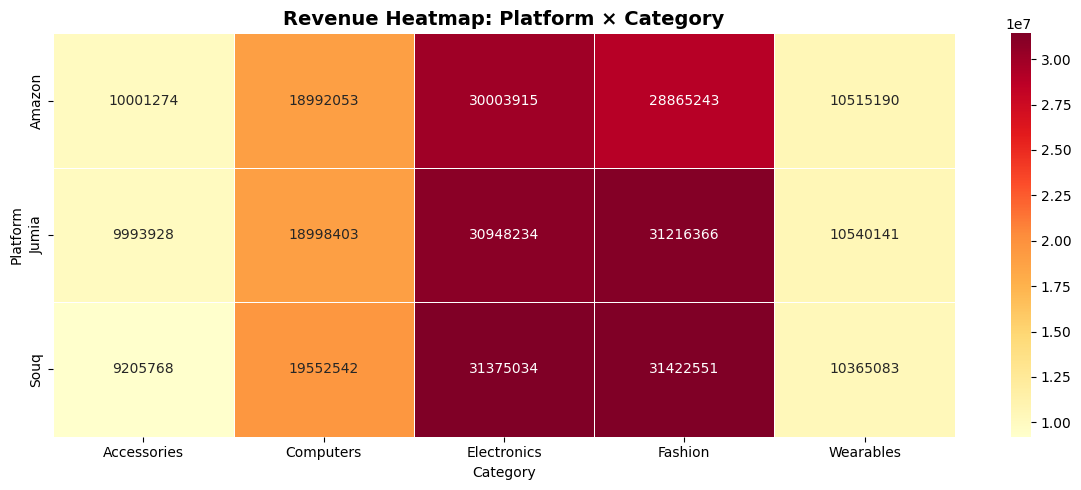

In [35]:
# Which platform sells which category the most?
pvt = df.pivot_table(
    values='TotalAmount',
    index='Platform',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(12, 5))
sns.heatmap(pvt, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Revenue Heatmap: Platform × Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

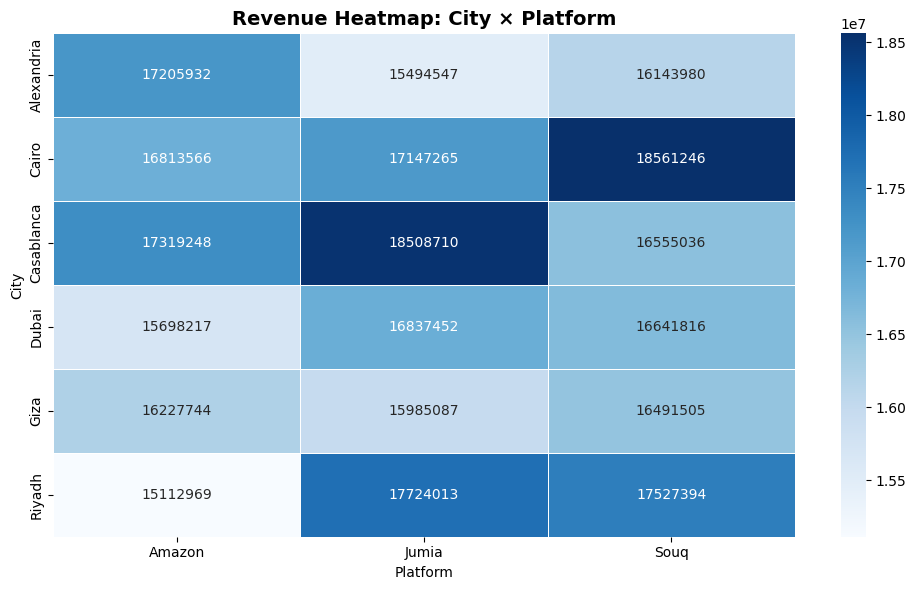

In [36]:
# Which platform dominates which city?
pvt_city = df.pivot_table(
    values='TotalAmount',
    index='City',
    columns='Platform',
    aggfunc='sum'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pvt_city, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5)
plt.title('Revenue Heatmap: City × Platform', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# Basic rating stats
print("⭐ RATING SUMMARY")
print("─" * 35)
print(f"  Mean Rating   : {df['Rating'].mean():.2f}")
print(f"  Median Rating : {df['Rating'].median():.2f}")
print(f"  Min Rating    : {df['Rating'].min():.2f}")
print(f"  Max Rating    : {df['Rating'].max():.2f}")
print(f"  Std Dev       : {df['Rating'].std():.2f}")

print("\n💬 REVIEW SUMMARY")
print("─" * 35)
print(f"  Total Reviews : {df['Reviews'].sum():,.0f}")
print(f"  Avg Reviews   : {df['Reviews'].mean():,.2f}")
print(f"  Max Reviews   : {df['Reviews'].max():,.0f}")

⭐ RATING SUMMARY
───────────────────────────────────
  Mean Rating   : 3.01
  Median Rating : 3.00
  Min Rating    : 1.00
  Max Rating    : 5.00
  Std Dev       : 1.15

💬 REVIEW SUMMARY
───────────────────────────────────
  Total Reviews : 25,200,722
  Avg Reviews   : 2,520.07
  Max Reviews   : 5,000


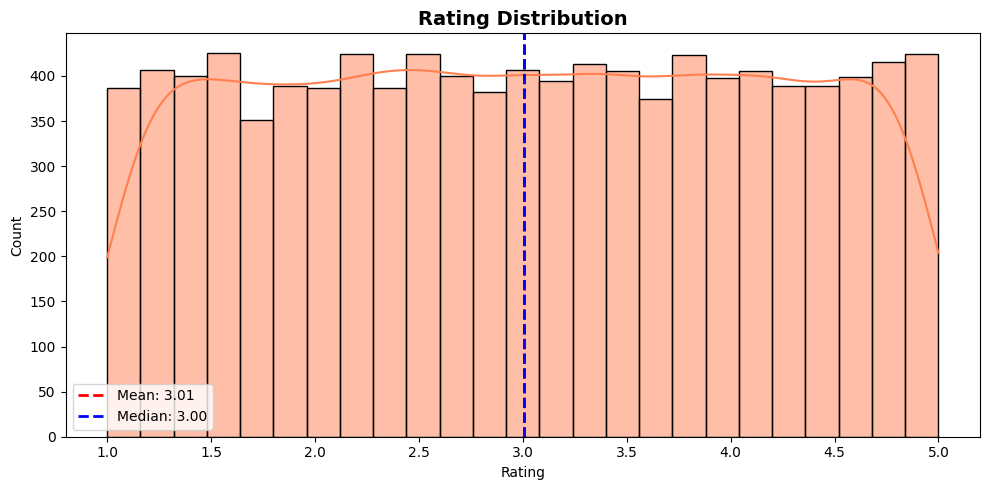

In [38]:
# Histogram with mean line
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=25, kde=True, color='coral')
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=2,
            label=f"Mean: {df['Rating'].mean():.2f}")
plt.axvline(df['Rating'].median(), color='blue', linestyle='--', linewidth=2,
            label=f"Median: {df['Rating'].median():.2f}")
plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.legend()
plt.tight_layout()
plt.show()

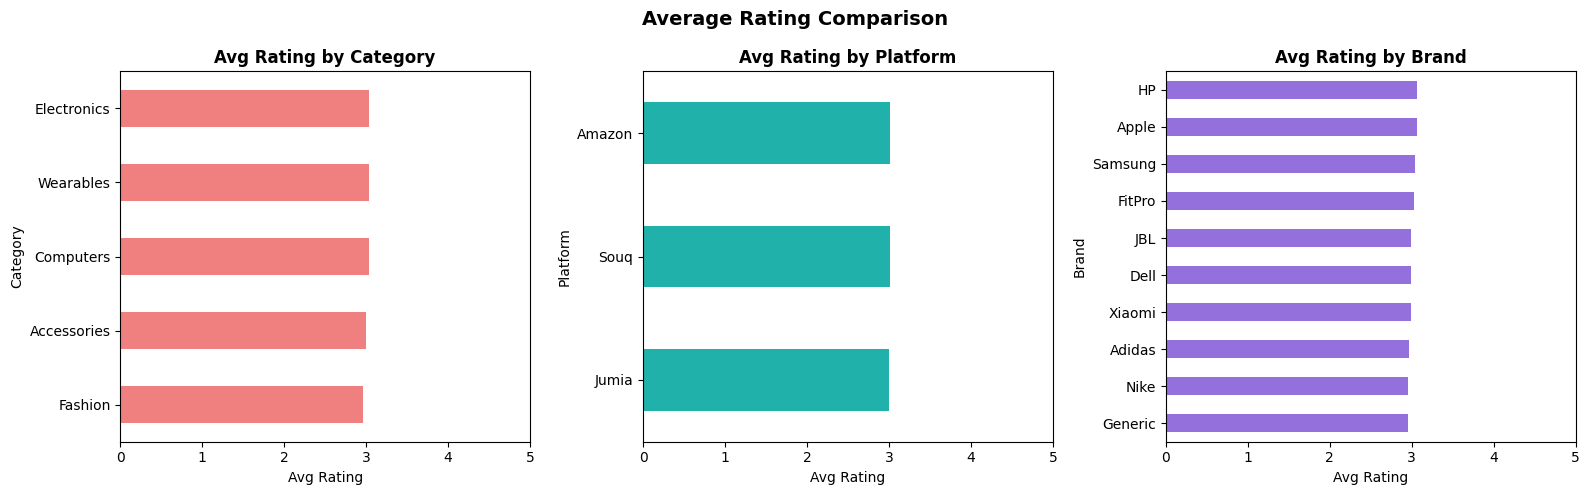

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By Category
df.groupby('Category')['Rating'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='lightcoral')
axes[0].set_title('Avg Rating by Category', fontweight='bold')
axes[0].set_xlabel('Avg Rating')
axes[0].set_xlim(0, 5)

# By Platform
df.groupby('Platform')['Rating'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='lightseagreen')
axes[1].set_title('Avg Rating by Platform', fontweight='bold')
axes[1].set_xlabel('Avg Rating')
axes[1].set_xlim(0, 5)

# By Brand
df.groupby('Brand')['Rating'].mean().sort_values().plot(
    kind='barh', ax=axes[2], color='mediumpurple')
axes[2].set_title('Avg Rating by Brand', fontweight='bold')
axes[2].set_xlabel('Avg Rating')
axes[2].set_xlim(0, 5)

plt.suptitle('Average Rating Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

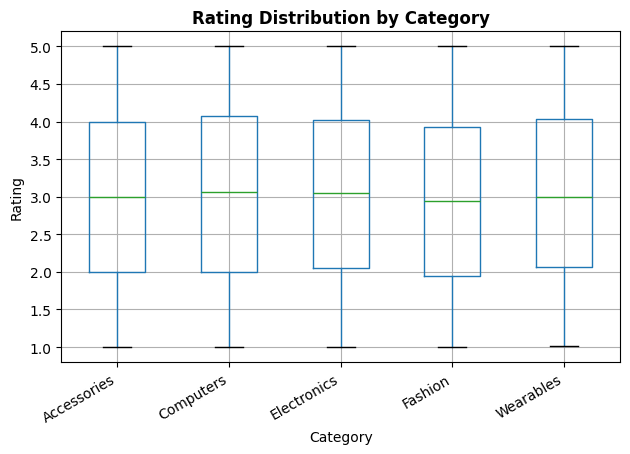

In [40]:
# Shows spread and outliers of ratings per category
plt.figure(figsize=(12, 5))
df.boxplot(column='Rating', by='Category')
plt.title('Rating Distribution by Category', fontweight='bold')
plt.suptitle('')
plt.xlabel('Category')
plt.ylabel('Rating')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

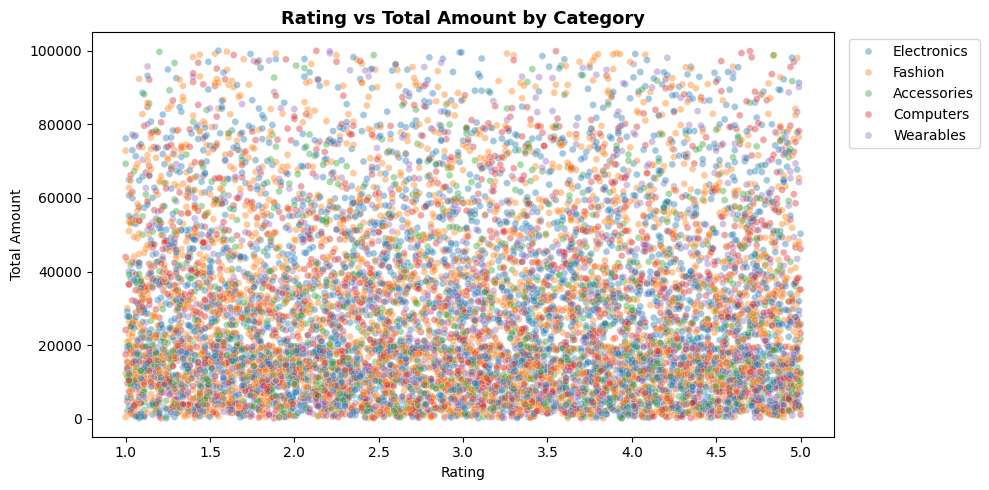


Pearson Correlation: r = 0.0004, p-value = 0.9668
Conclusion: No significant correlation (α=0.05)


In [41]:
# Does higher rating = higher revenue?
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Rating', y='TotalAmount',
                hue='Category', alpha=0.4, s=25)
plt.title('Rating vs Total Amount by Category', fontsize=13, fontweight='bold')
plt.ylabel('Total Amount')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Pearson correlation test
r, p = stats.pearsonr(df['Rating'], df['TotalAmount'])
print(f"\nPearson Correlation: r = {r:.4f}, p-value = {p:.4f}")
print(f"Conclusion: {'Significant' if p < 0.05 else 'No significant'} correlation (α=0.05)")

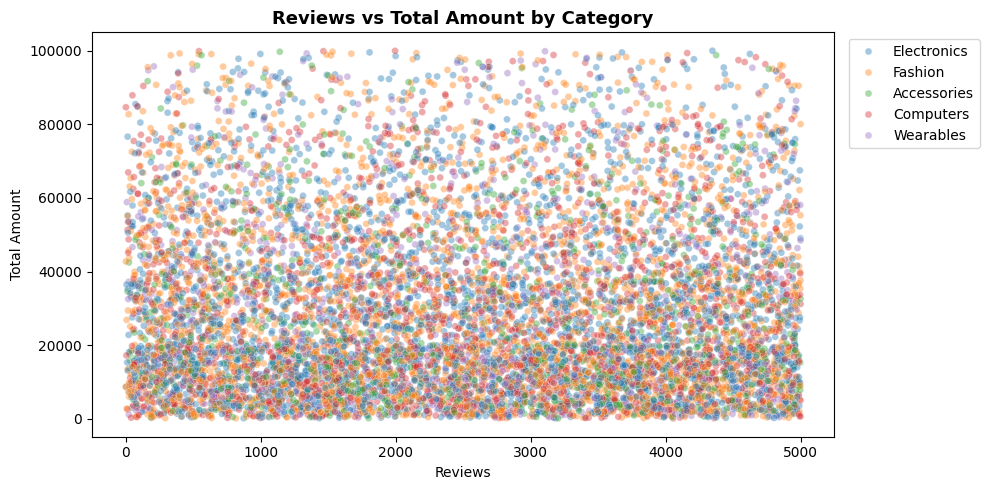


Pearson Correlation: r = -0.0074, p-value = 0.4618
Conclusion: No significant correlation (α=0.05)


In [42]:
# Does more reviews = more revenue?
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Reviews', y='TotalAmount',
                hue='Category', alpha=0.4, s=25)
plt.title('Reviews vs Total Amount by Category', fontsize=13, fontweight='bold')
plt.ylabel('Total Amount')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Pearson correlation test
r2, p2 = stats.pearsonr(df['Reviews'], df['TotalAmount'])
print(f"\nPearson Correlation: r = {r2:.4f}, p-value = {p2:.4f}")
print(f"Conclusion: {'Significant' if p2 < 0.05 else 'No significant'} correlation (α=0.05)")

⭐ RATING SEGMENT ANALYSIS
                Orders       Revenue  AvgOrder
RatingSegment                                 
Low (0-2)         2490  7.449308e+07  29916.90
Medium (2-3.5)    3773  1.136057e+08  30110.18
High (3.5-5)      3737  1.138969e+08  30478.17


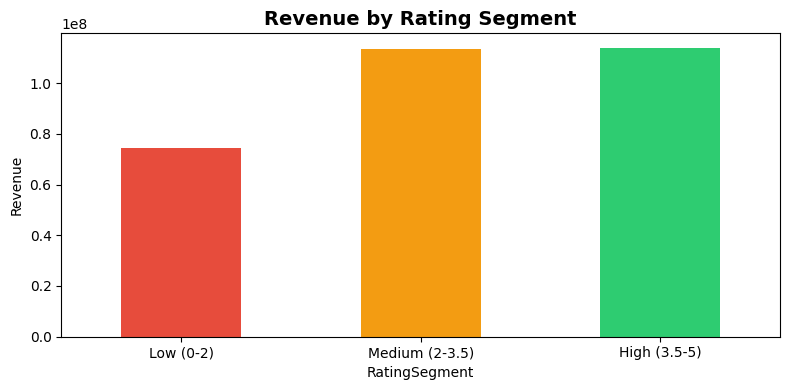

In [43]:
# Bin ratings into Low / Medium / High
df['RatingSegment'] = pd.cut(df['Rating'],
                              bins=[0, 2, 3.5, 5],
                              labels=['Low (0-2)', 'Medium (2-3.5)', 'High (3.5-5)'])

seg = df.groupby('RatingSegment').agg(
    Orders  = ('OrderID','count'),
    Revenue = ('TotalAmount','sum'),
    AvgOrder= ('TotalAmount','mean')
).round(2)

print("⭐ RATING SEGMENT ANALYSIS")
print(seg)

# Bar chart
seg['Revenue'].plot(kind='bar', figsize=(8, 4),
                    color=['#e74c3c','#f39c12','#2ecc71'])
plt.title('Revenue by Rating Segment', fontsize=14, fontweight='bold')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [44]:
# Count orders per day
daily = (df.groupby('OrderDate')['OrderID']
           .count()
           .reset_index())
daily.columns = ['Date', 'Orders']
daily = daily.sort_values('Date')

print(f"Date Range : {daily['Date'].min().date()} → {daily['Date'].max().date()}")
print(f"Total Days : {len(daily)}")
print(f"Avg Orders/Day: {daily['Orders'].mean():.1f}")

Date Range : 2024-01-01 → 2024-12-26
Total Days : 361
Avg Orders/Day: 27.7


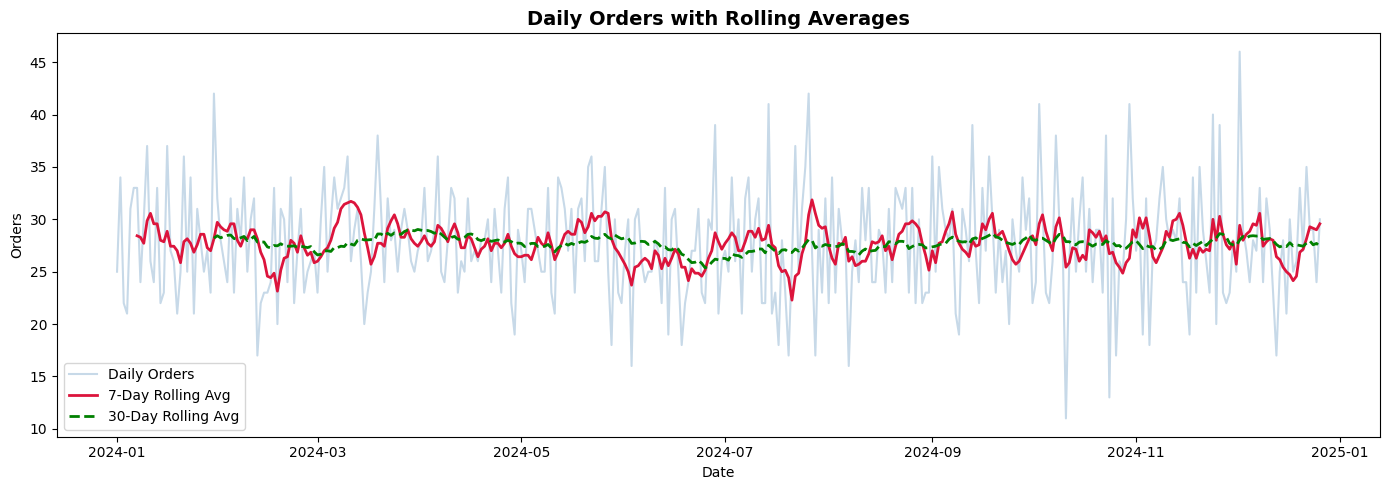

In [45]:
# 7-day rolling average smooths out daily noise
daily['Rolling7']  = daily['Orders'].rolling(7).mean()
daily['Rolling30'] = daily['Orders'].rolling(30).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily['Date'], daily['Orders'],
         alpha=0.3, color='steelblue', label='Daily Orders')
plt.plot(daily['Date'], daily['Rolling7'],
         color='crimson', linewidth=2, label='7-Day Rolling Avg')
plt.plot(daily['Date'], daily['Rolling30'],
         color='green', linewidth=2, linestyle='--', label='30-Day Rolling Avg')
plt.title('Daily Orders with Rolling Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Orders')
plt.legend()
plt.tight_layout()
plt.show()

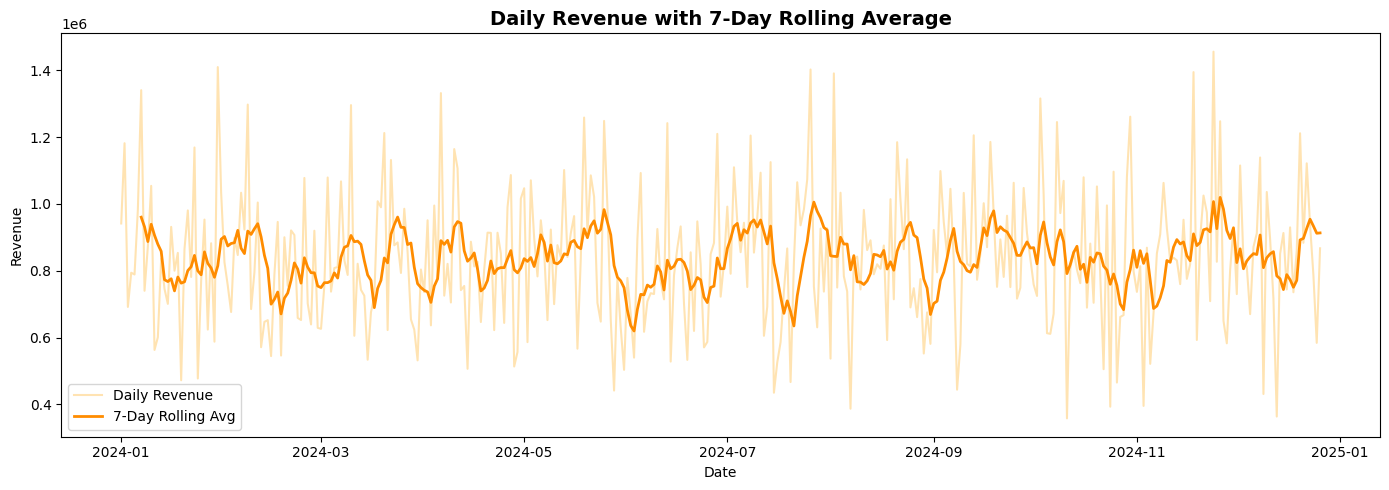

In [46]:
# Same but for revenue
daily_rev = (df.groupby('OrderDate')['TotalAmount']
               .sum()
               .reset_index())
daily_rev.columns = ['Date', 'Revenue']
daily_rev = daily_rev.sort_values('Date')
daily_rev['Rolling7'] = daily_rev['Revenue'].rolling(7).mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_rev['Date'], daily_rev['Revenue'],
         alpha=0.3, color='orange', label='Daily Revenue')
plt.plot(daily_rev['Date'], daily_rev['Rolling7'],
         color='darkorange', linewidth=2, label='7-Day Rolling Avg')
plt.title('Daily Revenue with 7-Day Rolling Average', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.tight_layout()
plt.show()

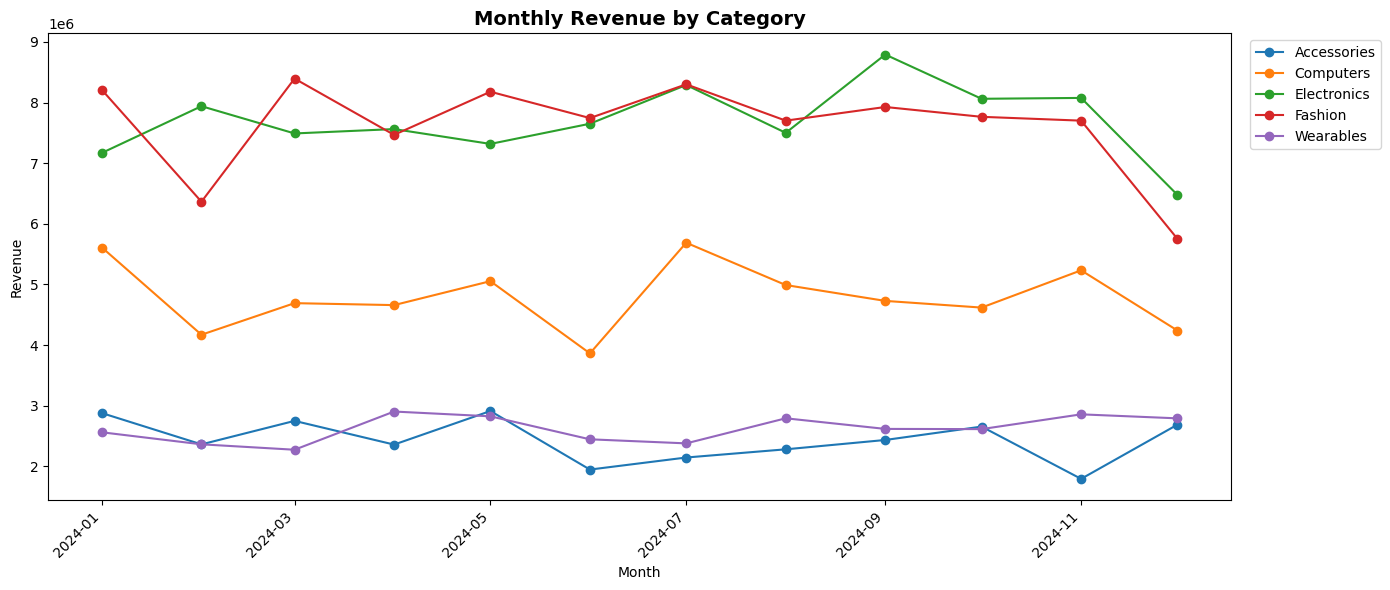

In [47]:
# See how each category trends month by month
cat_monthly = (df.groupby(['Year','Month','Category'])['TotalAmount']
                 .sum()
                 .reset_index())
cat_monthly['Period'] = pd.to_datetime(
    cat_monthly['Year'].astype(str) + '-' +
    cat_monthly['Month'].astype(str).str.zfill(2))

plt.figure(figsize=(14, 6))
for cat, grp in cat_monthly.groupby('Category'):
    grp_sorted = grp.sort_values('Period')
    plt.plot(grp_sorted['Period'], grp_sorted['TotalAmount'],
             marker='o', label=cat)

plt.title('Monthly Revenue by Category', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [48]:
# Find the single best month and best day
best_month = monthly.loc[monthly['TotalAmount'].idxmax()]
best_day   = daily_rev.loc[daily_rev['Revenue'].idxmax()]
best_dow   = df.groupby('DayOfWeek')['TotalAmount'].sum().idxmax()

print("📅 PEAK PERFORMANCE")
print("─" * 40)
print(f"  Best Month   : {best_month['Period']}  →  {best_month['TotalAmount']:,.2f}")
print(f"  Best Day     : {best_day['Date'].date()}  →  {best_day['Revenue']:,.2f}")
print(f"  Best Weekday : {best_dow}")

📅 PEAK PERFORMANCE
────────────────────────────────────────
  Best Month   : 2024-07  →  26,801,658.28
  Best Day     : 2024-11-24  →  1,455,547.01
  Best Weekday : Wednesday


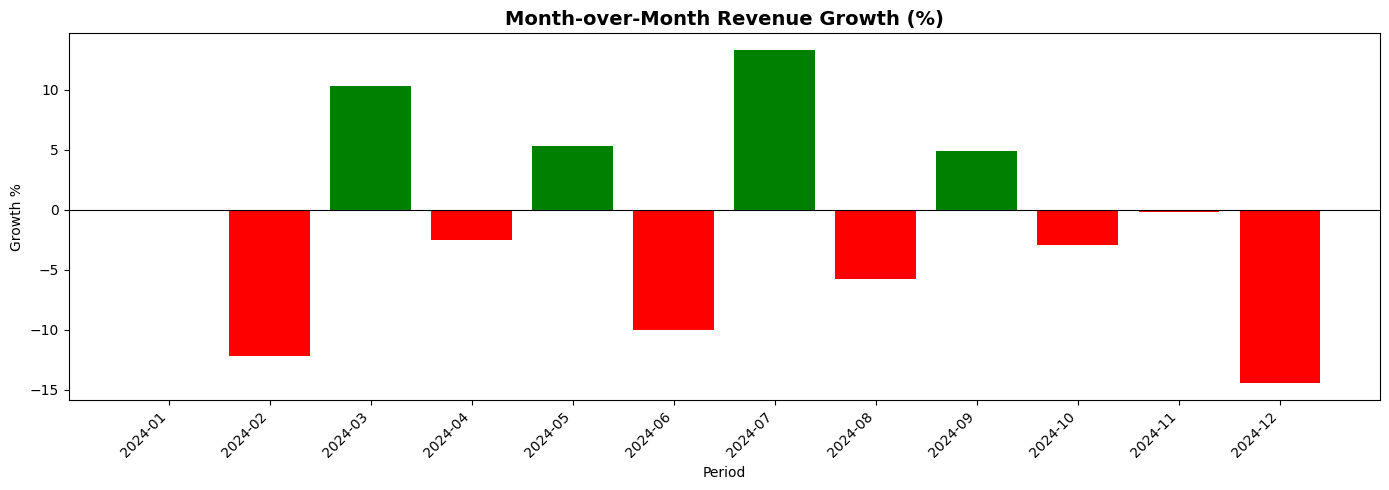

In [49]:
# % change in revenue from one month to the next
monthly_sorted = monthly.sort_values(['Year','Month']).copy()
monthly_sorted['MoM_Growth'] = monthly_sorted['TotalAmount'].pct_change() * 100

plt.figure(figsize=(14, 5))
colors = ['green' if x >= 0 else 'red' for x in monthly_sorted['MoM_Growth'].fillna(0)]
plt.bar(monthly_sorted['Period'], monthly_sorted['MoM_Growth'].fillna(0), color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Month-over-Month Revenue Growth (%)', fontsize=14, fontweight='bold')
plt.xlabel('Period')
plt.ylabel('Growth %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

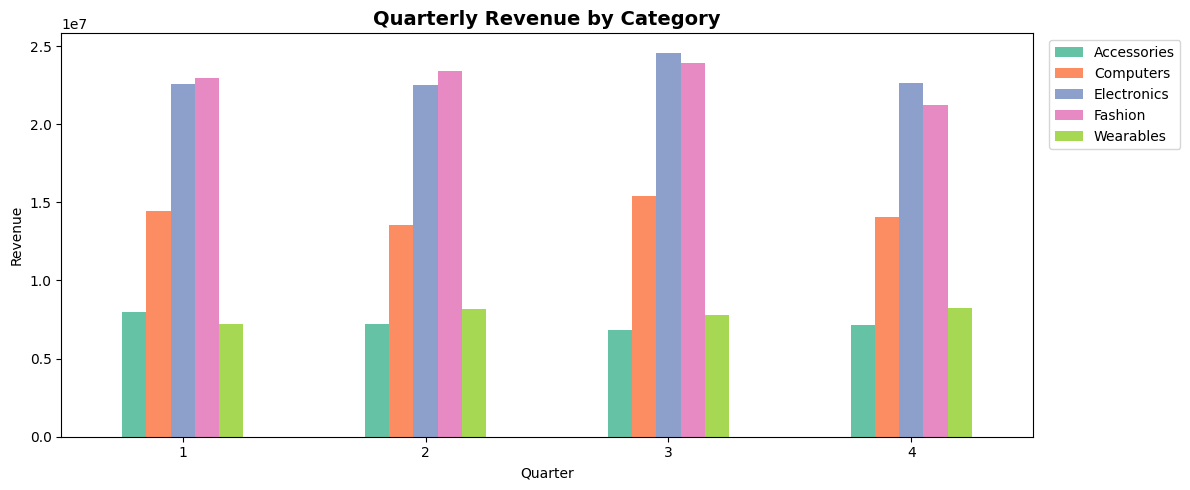

In [50]:
# Pivot: Quarter vs Category revenue
q_cat = df.groupby(['Quarter','Category'])['TotalAmount'].sum().unstack()

q_cat.plot(kind='bar', figsize=(12, 5),
           color=sns.color_palette('Set2', len(q_cat.columns)))
plt.title('Quarterly Revenue by Category', fontsize=14, fontweight='bold')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [52]:
# Installing R in Colab
!pip install -q rpy2
print("✅ rpy2 installed")

✅ rpy2 installed


In [53]:
# Load the rpy2 extension — must run before any %%R cell
%load_ext rpy2.ipython
print("✅ R extension loaded")

✅ R extension loaded


In [54]:
%%R
# Install required R packages (runs once, may take 1-2 minutes)
pkgs <- c('tidyverse', 'ggplot2', 'dplyr', 'lubridate',
          'scales', 'corrplot', 'ggthemes')

new_pkgs <- pkgs[!pkgs %in% installed.packages()[,'Package']]
if (length(new_pkgs)) {
  install.packages(new_pkgs, repos='https://cloud.r-project.org')
}

invisible(lapply(pkgs, library, character.only=TRUE))
cat("✅ All R packages loaded\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
✅ All R packages loaded


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/corrplot_0.95.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/ggthemes_5.2.0.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp59DfcH/downloaded_packages’

Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor

corrplot 0.95 loaded


In [55]:
# Pass the cleaned df from Python into R environment
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
pandas2ri.activate()

# Select core columns only
df_r = df[['OrderID','Product','Category','Brand','Platform',
           'City','Price','Quantity','TotalAmount',
           'Rating','Reviews','OrderDate']].copy()

ro.globalenv['df'] = df_r
print("✅ Dataframe transferred to R")
print(f"   Rows : {len(df_r):,}")
print(f"   Cols : {len(df_r.columns)}")

✅ Dataframe transferred to R
   Rows : 10,000
   Cols : 12


In [56]:
%%R
# Check the data arrived correctly in R
cat("=== DIMENSIONS ===\n")
cat("Rows:", nrow(df), "| Cols:", ncol(df), "\n")

cat("\n=== COLUMN NAMES ===\n")
print(names(df))

cat("\n=== FIRST 5 ROWS ===\n")
print(head(df, 5))

=== DIMENSIONS ===
Rows: 10000 | Cols: 12 

=== COLUMN NAMES ===
 [1] "OrderID"     "Product"     "Category"    "Brand"       "Platform"   
 [6] "City"        "Price"       "Quantity"    "TotalAmount" "Rating"     
[11] "Reviews"     "OrderDate"  

=== FIRST 5 ROWS ===
    OrderID            Product    Category   Brand Platform       City    Price
0 ORD100000 Samsung Galaxy A14 Electronics Samsung     Souq      Cairo 16284.02
1 ORD100001       Nike Air Max     Fashion    Nike    Jumia Alexandria  6645.20
2 ORD100002  Bluetooth Headset Accessories     JBL    Jumia Casablanca  8882.92
3 ORD100003 HP Pavilion Laptop   Computers      HP     Souq      Dubai  3665.44
4 ORD100004          iPhone 13 Electronics   Apple     Souq Casablanca  5210.37
  Quantity TotalAmount Rating Reviews  OrderDate
0        1    16284.02   1.39    1684 2024-11-11
1        2    13290.40   2.56    3604 2024-06-22
2        3    26648.76   4.98    1257 2024-05-27
3        1     3665.44   1.44     662 2024-07-25
4    

In [57]:
%%R
# Convert OrderDate and create Year, Month, Quarter columns
df$OrderDate <- as.Date(df$OrderDate)
df$Year      <- as.integer(format(df$OrderDate, "%Y"))
df$Month     <- as.integer(format(df$OrderDate, "%m"))
df$Quarter   <- ceiling(df$Month / 3)
df$DayOfWeek <- weekdays(df$OrderDate)
df$MonthYear <- format(df$OrderDate, "%Y-%m")

cat("✅ Date columns created\n")
cat("Date range:", format(min(df$OrderDate)),
    "to", format(max(df$OrderDate)), "\n")

✅ Date columns created
Date range: 2024-01-01 to 2024-12-26 


In [58]:
%%R
# Quick overview of all columns
cat("=== DATA TYPES ===\n")
str(df)

cat("\n=== NUMERIC SUMMARY ===\n")
summary(df[, c('Price','Quantity','TotalAmount','Rating','Reviews')])

=== DATA TYPES ===
'data.frame':	10000 obs. of  17 variables:
 $ OrderID    : chr  "ORD100000" "ORD100001" "ORD100002" "ORD100003" ...
 $ Product    : chr  "Samsung Galaxy A14" "Nike Air Max" "Bluetooth Headset" "HP Pavilion Laptop" ...
 $ Category   : chr  "Electronics" "Fashion" "Accessories" "Computers" ...
 $ Brand      : chr  "Samsung" "Nike" "JBL" "HP" ...
 $ Platform   : chr  "Souq" "Jumia" "Jumia" "Souq" ...
 $ City       : chr  "Cairo" "Alexandria" "Casablanca" "Dubai" ...
 $ Price      : num  16284 6645 8883 3665 5210 ...
 $ Quantity   : int  1 2 3 1 2 5 2 3 5 3 ...
 $ TotalAmount: num  16284 13290 26649 3665 10421 ...
 $ Rating     : num  1.39 2.56 4.98 1.44 3.73 3.91 4.18 2.98 1.17 2.05 ...
 $ Reviews    : int  1684 3604 1257 662 2424 2154 4309 3504 178 4589 ...
 $ OrderDate  : Date, format: "2024-11-11" "2024-06-22" ...
 $ Year       : int  2024 2024 2024 2024 2024 2024 2024 2024 2024 2024 ...
 $ Month      : int  11 6 5 7 2 9 7 1 9 9 ...
 $ Quarter    : num  4 2 2 3 1 3 3

In [59]:
%%R
# Overall business KPIs using dplyr
kpis <- df %>%
  summarise(
    Total_Orders     = n(),
    Total_Revenue    = sum(TotalAmount),
    Avg_Order_Value  = round(mean(TotalAmount), 2),
    Total_Units_Sold = sum(Quantity),
    Avg_Rating       = round(mean(Rating), 2),
    Total_Reviews    = sum(Reviews)
  )

cat("📊 KPI SUMMARY\n")
cat(rep("─", 40), "\n")
print(t(kpis))  # t() transposes for easier reading

📊 KPI SUMMARY
─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ ─ 
                         [,1]
Total_Orders         10000.00
Total_Revenue    301995724.39
Avg_Order_Value      30199.57
Total_Units_Sold     30062.00
Avg_Rating               3.01
Total_Reviews     25200722.00


In [60]:
%%R
# Revenue, orders, avg rating and avg price per category
cat_summary <- df %>%
  group_by(Category) %>%
  summarise(
    Revenue   = sum(TotalAmount),
    Orders    = n(),
    AvgRating = round(mean(Rating), 2),
    AvgPrice  = round(mean(Price), 2),
    TotalUnits= sum(Quantity)
  ) %>%
  arrange(desc(Revenue))

cat("📦 CATEGORY SUMMARY\n")
print(cat_summary)

📦 CATEGORY SUMMARY
# A tibble: 5 × 6
  Category      Revenue Orders AvgRating AvgPrice TotalUnits
  <chr>           <dbl>  <int>     <dbl>    <dbl>      <int>
1 Electronics 92327184.   3028      3.03   10140.       9036
2 Fashion     91504160.   2970      2.96   10160.       8980
3 Computers   57542998.   1953      3.03    9802.       5892
4 Wearables   31420413.   1020      3.03   10064.       3111
5 Accessories 29200970.   1029      3       9710.       3043


In [61]:
%%R
# Brand performance ranked by revenue
brand_summary <- df %>%
  group_by(Brand) %>%
  summarise(
    Revenue   = sum(TotalAmount),
    Orders    = n(),
    AvgPrice  = round(mean(Price), 2),
    AvgRating = round(mean(Rating), 2)
  ) %>%
  arrange(desc(Revenue))

cat("🏷️ BRAND SUMMARY\n")
print(brand_summary)

🏷️ BRAND SUMMARY
# A tibble: 10 × 5
   Brand     Revenue Orders AvgPrice AvgRating
   <chr>       <dbl>  <int>    <dbl>     <dbl>
 1 Xiaomi  33772598.   1030   10422.      2.99
 2 FitPro  31420413.   1020   10064.      3.03
 3 Nike    30727638.   1005   10107.      2.96
 4 Generic 30507500.    997   10030.      2.95
 5 Adidas  30269022.    968   10350.      2.97
 6 Samsung 30004263.   1043    9886.      3.05
 7 HP      29482727.    991   10012.      3.07
 8 JBL     29200970.   1029    9710.      3   
 9 Apple   28550322.    955   10114.      3.06
10 Dell    28060270.    962    9585.      2.99


In [62]:
%%R
# Platform performance
platform_summary <- df %>%
  group_by(Platform) %>%
  summarise(
    Revenue   = sum(TotalAmount),
    Orders    = n(),
    AvgOrder  = round(mean(TotalAmount), 2),
    AvgRating = round(mean(Rating), 2)
  ) %>%
  arrange(desc(Revenue))

cat("🛒 PLATFORM SUMMARY\n")
print(platform_summary)

🛒 PLATFORM SUMMARY
# A tibble: 3 × 5
  Platform    Revenue Orders AvgOrder AvgRating
  <chr>         <dbl>  <int>    <dbl>     <dbl>
1 Souq     101920977.   3371   30235.      3.01
2 Jumia    101697072.   3341   30439.      3   
3 Amazon    98377675.   3288   29920.      3.01


In [63]:
%%R
# City performance
city_summary <- df %>%
  group_by(City) %>%
  summarise(
    Revenue  = sum(TotalAmount),
    Orders   = n(),
    AvgOrder = round(mean(TotalAmount), 2)
  ) %>%
  arrange(desc(Revenue))

cat("🏙️ CITY SUMMARY\n")
print(city_summary)

🏙️ CITY SUMMARY
# A tibble: 6 × 4
  City         Revenue Orders AvgOrder
  <chr>          <dbl>  <int>    <dbl>
1 Cairo      52522077.   1705   30805.
2 Casablanca 52382994.   1689   31014.
3 Riyadh     50364376.   1679   29997.
4 Dubai      49177484.   1648   29841.
5 Alexandria 48844459.   1657   29478.
6 Giza       48704335.   1622   30027.


In [64]:
%%R
# Revenue grouped by Year and Month
monthly_rev <- df %>%
  group_by(Year, Month) %>%
  summarise(
    Revenue = sum(TotalAmount),
    Orders  = n(),
    .groups = 'drop'
  ) %>%
  arrange(Year, Month)

cat("📅 MONTHLY REVENUE\n")
print(monthly_rev)

📅 MONTHLY REVENUE
# A tibble: 12 × 4
    Year Month   Revenue Orders
   <int> <int>     <dbl>  <int>
 1  2024     1 26425905.    878
 2  2024     2 23199060.    775
 3  2024     3 25599416.    894
 4  2024     4 24950411.    832
 5  2024     5 26286509.    871
 6  2024     6 23649020.    788
 7  2024     7 26801658.    855
 8  2024     8 25264032.    841
 9  2024     9 26498388.    855
10  2024    10 25713674.    858
11  2024    11 25660914.    827
12  2024    12 21946737.    726


In [65]:
%%R
# Cross table: which platform sells which category most
pivot_plat_cat <- df %>%
  group_by(Platform, Category) %>%
  summarise(Revenue = sum(TotalAmount), .groups='drop') %>%
  tidyr::pivot_wider(
    names_from  = Category,
    values_from = Revenue,
    values_fill = 0
  )

cat("📊 PLATFORM × CATEGORY REVENUE PIVOT\n")
print(pivot_plat_cat)

📊 PLATFORM × CATEGORY REVENUE PIVOT
# A tibble: 3 × 6
  Platform Accessories Computers Electronics   Fashion Wearables
  <chr>          <dbl>     <dbl>       <dbl>     <dbl>     <dbl>
1 Amazon     10001274. 18992053.   30003915. 28865243. 10515190.
2 Jumia       9993928. 18998403.   30948234. 31216366. 10540141.
3 Souq        9205768. 19552542.   31375034. 31422551. 10365083.


In [66]:
%%R
# Bin ratings into Low / Medium / High segments
df$RatingSegment <- cut(df$Rating,
                        breaks = c(0, 2, 3.5, 5),
                        labels = c('Low (0-2)',
                                   'Medium (2-3.5)',
                                   'High (3.5-5)'))

seg_summary <- df %>%
  group_by(RatingSegment) %>%
  summarise(
    Orders   = n(),
    Revenue  = sum(TotalAmount),
    AvgOrder = round(mean(TotalAmount), 2)
  )

cat("⭐ RATING SEGMENT SUMMARY\n")
print(seg_summary)

⭐ RATING SEGMENT SUMMARY
# A tibble: 3 × 4
  RatingSegment  Orders    Revenue AvgOrder
  <fct>           <int>      <dbl>    <dbl>
1 Low (0-2)        2490  74493076.   29917.
2 Medium (2-3.5)   3773 113605713.   30110.
3 High (3.5-5)     3737 113896935.   30478.


In [67]:
%%R
# Correlation between all numeric variables
num_data   <- df[, c('Price','Quantity','TotalAmount','Rating','Reviews')]
cor_matrix <- cor(num_data)

cat("📊 CORRELATION MATRIX\n")
print(round(cor_matrix, 3))

📊 CORRELATION MATRIX
             Price Quantity TotalAmount Rating Reviews
Price        1.000    0.007       0.727 -0.007  -0.003
Quantity     0.007    1.000       0.602  0.000  -0.007
TotalAmount  0.727    0.602       1.000  0.000  -0.007
Rating      -0.007    0.000       0.000  1.000  -0.005
Reviews     -0.003   -0.007      -0.007 -0.005   1.000


In [68]:
%%R
# Test if each correlation is statistically significant
library(corrplot)

# Pairwise correlation with p-values
cor_test_result <- cor.mtest(num_data, conf.level=0.95)

cat("p-values for each correlation pair:\n")
print(round(cor_test_result$p, 4))

p-values for each correlation pair:
             Price Quantity TotalAmount Rating Reviews
Price       0.0000   0.5098      0.0000 0.4616  0.7537
Quantity    0.5098   0.0000      0.0000 0.9875  0.5047
TotalAmount 0.0000   0.0000      0.0000 0.9668  0.4618
Rating      0.4616   0.9875      0.9668 0.0000  0.6447
Reviews     0.7537   0.5047      0.4618 0.6447  0.0000


In [69]:
%%R
# Does platform significantly affect TotalAmount?
anova_platform <- aov(TotalAmount ~ Platform, data=df)

cat("📊 ANOVA — TotalAmount ~ Platform\n")
print(summary(anova_platform))

# Interpretation
p_val <- summary(anova_platform)[[1]][['Pr(>F)']][1]
cat("\nConclusion:",
    ifelse(p_val < 0.05,
           "✅ Significant difference between platforms (p < 0.05)",
           "❌ No significant difference between platforms (p > 0.05)"), "\n")

📊 ANOVA — TotalAmount ~ Platform
              Df    Sum Sq   Mean Sq F value Pr(>F)
Platform       2 4.524e+08 226221227   0.397  0.672
Residuals   9997 5.693e+12 569453667               

Conclusion: ❌ No significant difference between platforms (p > 0.05) 


📊 TUKEY HSD — Pairwise Platform Comparison
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = TotalAmount ~ Platform, data = df)

$Platform
                  diff        lwr      upr     p adj
Jumia-Amazon  518.8944  -855.1982 1892.987 0.6496900
Souq-Amazon   314.4243 -1056.6323 1685.481 0.8528096
Souq-Jumia   -204.4701 -1570.0104 1161.070 0.9343525



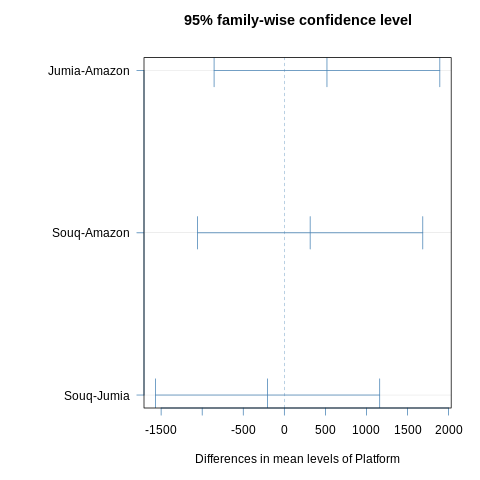

In [72]:
%%R
# Which specific platform pairs are significantly different?
tukey_platform <- TukeyHSD(anova_platform)

cat("📊 TUKEY HSD — Pairwise Platform Comparison\n")
print(tukey_platform)

# Plot Tukey result
par(mar=c(5,10,4,2)) #adjusts margin so the labels fit
plot(tukey_platform, las=1, col='steelblue')

In [73]:
%%R
# Does category significantly affect TotalAmount?
anova_category <- aov(TotalAmount ~ Category, data=df)

cat("📊 ANOVA — TotalAmount ~ Category\n")
print(summary(anova_category))

p_val2 <- summary(anova_category)[[1]][['Pr(>F)']][1]
cat("\nConclusion:",
    ifelse(p_val2 < 0.05,
           "✅ Significant difference between categories (p < 0.05)",
           "❌ No significant difference between categories (p > 0.05)"), "\n")

📊 ANOVA — TotalAmount ~ Category
              Df    Sum Sq   Mean Sq F value Pr(>F)  
Category       4 6.207e+09 1.552e+09   2.727 0.0277 *
Residuals   9995 5.687e+12 5.690e+08                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Conclusion: ✅ Significant difference between categories (p < 0.05) 


In [74]:
%%R
# Which category pairs differ significantly?
tukey_category <- TukeyHSD(anova_category)

cat("📊 TUKEY HSD — Pairwise Category Comparison\n")
print(tukey_category)

📊 TUKEY HSD — Pairwise Category Comparison
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = TotalAmount ~ Category, data = df)

$Category
                               diff         lwr      upr     p adj
Computers-Accessories   1085.892539 -1421.00068 3592.786 0.7618930
Electronics-Accessories 2113.136013  -235.18631 4461.458 0.1011737
Fashion-Accessories     2431.473490    77.34255 4785.604 0.0389089
Wearables-Accessories   2426.318766  -449.11938 5301.757 0.1441771
Electronics-Computers   1027.243473  -861.48722 2915.974 0.5730400
Fashion-Computers       1345.580950  -550.36694 3241.529 0.2980653
Wearables-Computers     1340.426226 -1173.69996 3854.552 0.5921658
Fashion-Electronics      318.337477 -1362.35360 1999.029 0.9857173
Wearables-Electronics    313.182753 -2042.85939 2669.225 0.9963124
Wearables-Fashion         -5.154724 -2366.98650 2356.677 1.0000000



In [75]:
%%R
# Does Price predict TotalAmount?
lm_simple <- lm(TotalAmount ~ Price, data=df)

cat("📊 SIMPLE LINEAR REGRESSION — TotalAmount ~ Price\n")
print(summary(lm_simple))

cat("\nInterpretation:\n")
cat("  R-squared :", round(summary(lm_simple)$r.squared, 4), "\n")
cat("  For every 1 unit increase in Price,",
    "TotalAmount changes by",
    round(coef(lm_simple)[2], 2), "\n")

📊 SIMPLE LINEAR REGRESSION — TotalAmount ~ Price

Call:
lm(formula = TotalAmount ~ Price, data = df)

Residuals:
   Min     1Q Median     3Q    Max 
-40378  -9963   -104  10206  39613 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -155.17922  330.52658  -0.469    0.639    
Price          3.02700    0.02862 105.764   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 16390 on 9998 degrees of freedom
Multiple R-squared:  0.528,	Adjusted R-squared:  0.528 
F-statistic: 1.119e+04 on 1 and 9998 DF,  p-value: < 2.2e-16


Interpretation:
  R-squared : 0.528 
  For every 1 unit increase in Price, TotalAmount changes by 3.03 


In [76]:
%%R
# Do Price + Quantity + Rating together predict TotalAmount?
lm_multi <- lm(TotalAmount ~ Price + Quantity + Rating, data=df)

cat("📊 MULTIPLE LINEAR REGRESSION\n")
cat("   TotalAmount ~ Price + Quantity + Rating\n\n")
print(summary(lm_multi))

cat("\nKey Metrics:\n")
cat("  R-squared        :", round(summary(lm_multi)$r.squared, 4), "\n")
cat("  Adj R-squared    :", round(summary(lm_multi)$adj.r.squared, 4), "\n")
cat("  F-statistic p-val:", pf(summary(lm_multi)$fstatistic[1],
                               summary(lm_multi)$fstatistic[2],
                               summary(lm_multi)$fstatistic[3],
                               lower.tail=FALSE), "\n")

📊 MULTIPLE LINEAR REGRESSION
   TotalAmount ~ Price + Quantity + Rating


Call:
lm(formula = TotalAmount ~ Price + Quantity + Rating, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-20169.9  -5019.3    -59.7   5058.6  20166.8 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -3.063e+04  3.171e+02 -96.581   <2e-16 ***
Price        3.011e+00  1.412e-02 213.187   <2e-16 ***
Quantity     1.007e+04  5.715e+01 176.257   <2e-16 ***
Rating       1.166e+02  7.005e+01   1.665    0.096 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8089 on 9996 degrees of freedom
Multiple R-squared:  0.8851,	Adjusted R-squared:  0.8851 
F-statistic: 2.567e+04 on 3 and 9996 DF,  p-value: < 2.2e-16


Key Metrics:
  R-squared        : 0.8851 
  Adj R-squared    : 0.8851 
  F-statistic p-val: 0 


In [77]:
%%R
# Are Platform and Category independent of each other?
chi_table <- table(df$Platform, df$Category)

cat("📊 CONTINGENCY TABLE — Platform × Category\n")
print(chi_table)

chi_result <- chisq.test(chi_table)
cat("\nChi-Square Test Result:\n")
print(chi_result)

cat("\nConclusion:",
    ifelse(chi_result$p.value < 0.05,
           "✅ Platform and Category are NOT independent (p < 0.05)",
           "❌ Platform and Category are independent (p > 0.05)"), "\n")

📊 CONTINGENCY TABLE — Platform × Category
        
         Accessories Computers Electronics Fashion Wearables
  Amazon         362       638         976     957       355
  Jumia          330       661        1006    1012       332
  Souq           337       654        1046    1001       333

Chi-Square Test Result:

	Pearson's Chi-squared test

data:  chi_table
X-squared = 6.1981, df = 8, p-value = 0.6251


Conclusion: ❌ Platform and Category are independent (p > 0.05) 


In [78]:
%%R
# Compare avg TotalAmount between Amazon and Jumia
amazon <- df$TotalAmount[df$Platform == 'Amazon']
jumia  <- df$TotalAmount[df$Platform == 'Jumia']

t_result <- t.test(amazon, jumia)

cat("📊 T-TEST — Amazon vs Jumia (TotalAmount)\n")
print(t_result)

cat("\nConclusion:",
    ifelse(t_result$p.value < 0.05,
           "✅ Significant difference in avg order value (p < 0.05)",
           "❌ No significant difference in avg order value (p > 0.05)"), "\n")

📊 T-TEST — Amazon vs Jumia (TotalAmount)

	Welch Two Sample t-test

data:  amazon and jumia
t = -0.88361, df = 6625.1, p-value = 0.3769
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -1670.078   632.289
sample estimates:
mean of x mean of y 
 29920.22  30439.11 


Conclusion: ❌ No significant difference in avg order value (p > 0.05) 


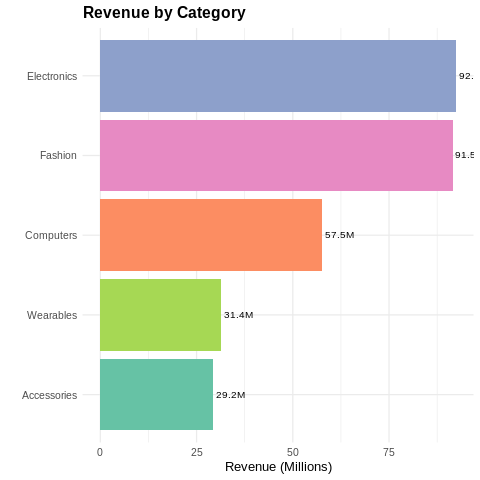

In [79]:
%%R
ggplot(cat_summary, aes(x=reorder(Category, Revenue),
                         y=Revenue/1e6, fill=Category)) +
  geom_col(show.legend=FALSE) +
  geom_text(aes(label=sprintf('%.1fM', Revenue/1e6)),
            hjust=-0.1, size=3.5) +
  coord_flip() +
  scale_fill_brewer(palette='Set2') +
  labs(title='Revenue by Category',
       x='', y='Revenue (Millions)') +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'))

`geom_smooth()` using formula = 'y ~ x'


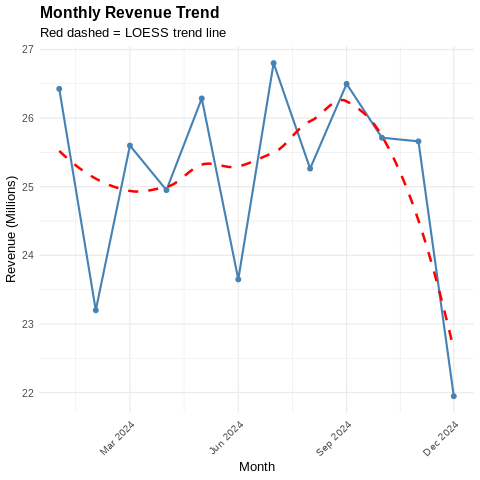

In [80]:
%%R
# Create period column for plotting
monthly_plot <- df %>%
  mutate(YearMonth = as.Date(paste(Year, Month, '01', sep='-'))) %>%
  group_by(YearMonth) %>%
  summarise(Revenue = sum(TotalAmount), .groups='drop')

ggplot(monthly_plot, aes(x=YearMonth, y=Revenue/1e6)) +
  geom_line(color='steelblue', linewidth=1) +
  geom_point(color='steelblue', size=2) +
  geom_smooth(method='loess', color='red',
              linetype='dashed', se=FALSE) +
  scale_x_date(date_labels='%b %Y', date_breaks='3 months') +
  labs(title='Monthly Revenue Trend',
       subtitle='Red dashed = LOESS trend line',
       x='Month', y='Revenue (Millions)') +
  theme_minimal(base_size=13) +
  theme(axis.text.x=element_text(angle=45, hjust=1),
        plot.title=element_text(face='bold'))

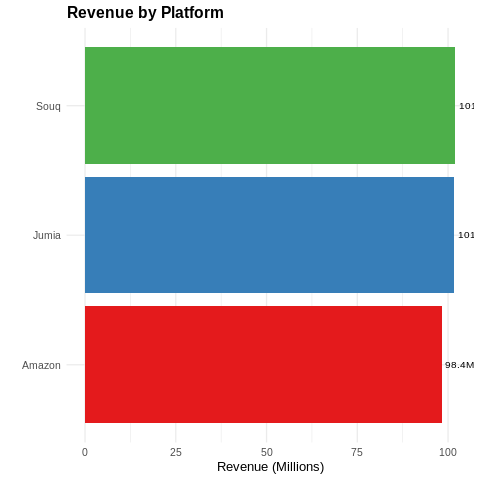

In [81]:
%%R
ggplot(platform_summary, aes(x=reorder(Platform, Revenue),
                              y=Revenue/1e6, fill=Platform)) +
  geom_col(show.legend=FALSE) +
  geom_text(aes(label=sprintf('%.1fM', Revenue/1e6)),
            hjust=-0.1, size=3.5) +
  coord_flip() +
  scale_fill_brewer(palette='Set1') +
  labs(title='Revenue by Platform',
       x='', y='Revenue (Millions)') +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'))

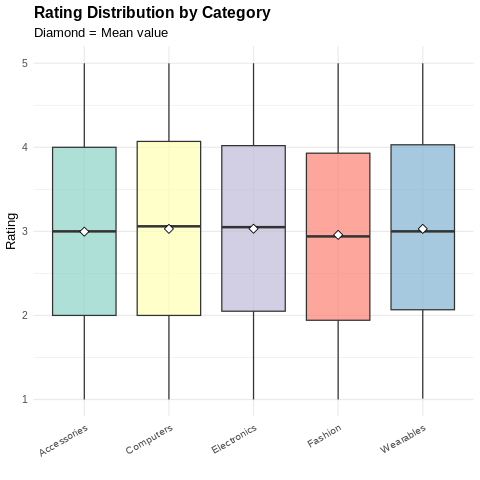

In [82]:
%%R
ggplot(df, aes(x=Category, y=Rating, fill=Category)) +
  geom_boxplot(alpha=0.7, outlier.alpha=0.3) +
  stat_summary(fun=mean, geom='point',
               shape=23, size=3, fill='white') +
  scale_fill_brewer(palette='Set3') +
  labs(title='Rating Distribution by Category',
       subtitle='Diamond = Mean value',
       x='', y='Rating') +
  theme_minimal(base_size=13) +
  theme(legend.position='none',
        axis.text.x=element_text(angle=30, hjust=1),
        plot.title=element_text(face='bold'))

`geom_smooth()` using formula = 'y ~ x'


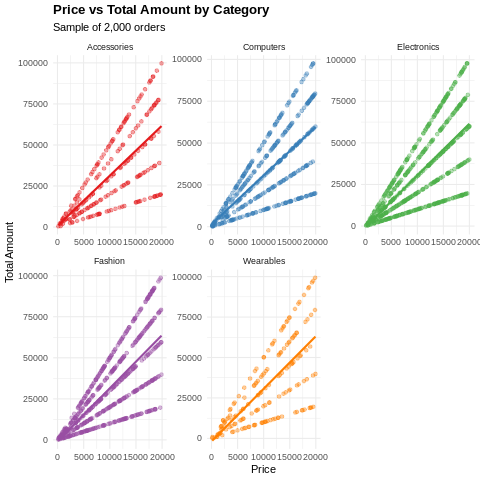

In [83]:
%%R
# Sample 2000 rows to avoid overplotting
set.seed(42)
df_sample <- df[sample(nrow(df), 2000), ]

ggplot(df_sample, aes(x=Price, y=TotalAmount, color=Category)) +
  geom_point(alpha=0.4, size=1.5) +
  geom_smooth(method='lm', se=FALSE, linewidth=1) +
  facet_wrap(~Category, scales='free') +
  scale_color_brewer(palette='Set1') +
  labs(title='Price vs Total Amount by Category',
       subtitle='Sample of 2,000 orders',
       x='Price', y='Total Amount') +
  theme_minimal(base_size=11) +
  theme(legend.position='none',
        plot.title=element_text(face='bold'))

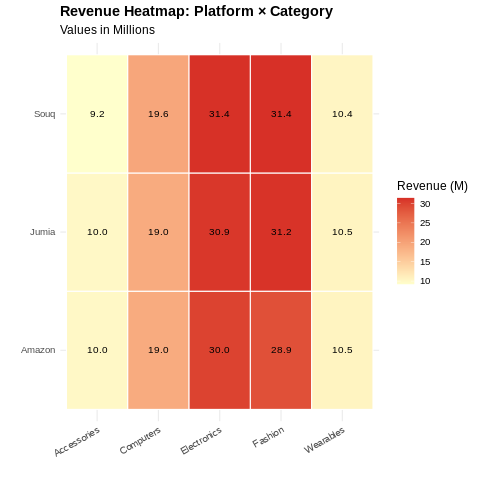

In [84]:
%%R
heat_data <- df %>%
  group_by(Platform, Category) %>%
  summarise(Revenue=sum(TotalAmount)/1e6, .groups='drop')

ggplot(heat_data, aes(x=Category, y=Platform, fill=Revenue)) +
  geom_tile(color='white', linewidth=0.5) +
  geom_text(aes(label=sprintf('%.1f', Revenue)),
            size=3.5, color='black') +
  scale_fill_gradient(low='#ffffcc', high='#d73027',
                      name='Revenue (M)') +
  labs(title='Revenue Heatmap: Platform × Category',
       subtitle='Values in Millions',
       x='', y='') +
  theme_minimal(base_size=12) +
  theme(axis.text.x=element_text(angle=30, hjust=1),
        plot.title=element_text(face='bold'))

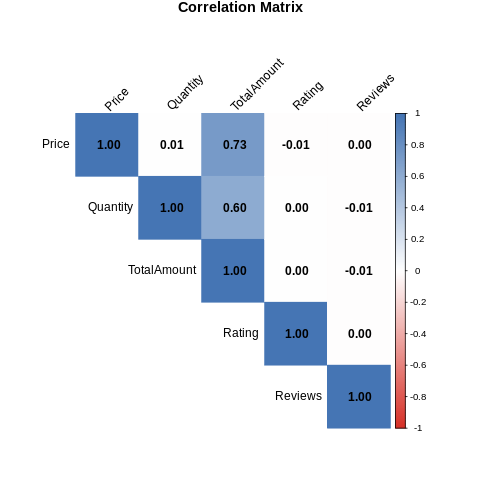

In [85]:
%%R
library(corrplot)

corrplot(cor_matrix,
         method   = 'color',
         type     = 'upper',
         addCoef.col = 'black',
         tl.col   = 'black',
         tl.srt   = 45,
         col      = colorRampPalette(c('#d73027','white','#4575b4'))(200),
         title    = 'Correlation Matrix',
         mar      = c(0,0,1,0))

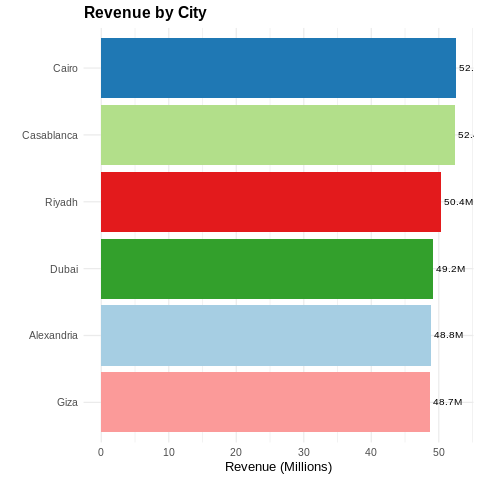

In [86]:
%%R
ggplot(city_summary, aes(x=reorder(City, Revenue),
                          y=Revenue/1e6, fill=City)) +
  geom_col(show.legend=FALSE) +
  geom_text(aes(label=sprintf('%.1fM', Revenue/1e6)),
            hjust=-0.1, size=3.5) +
  coord_flip() +
  scale_fill_brewer(palette='Paired') +
  labs(title='Revenue by City',
       x='', y='Revenue (Millions)') +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'))

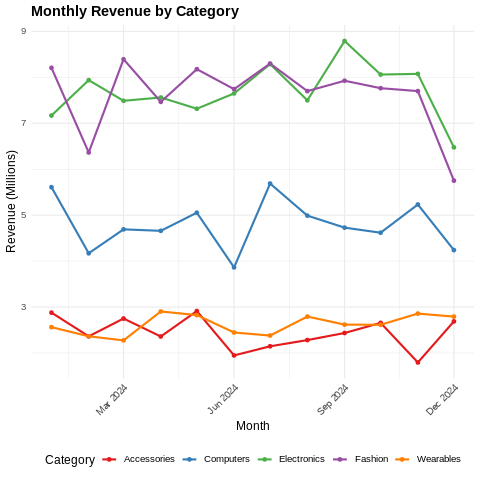

In [87]:
%%R
cat_monthly_plot <- df %>%
  mutate(YearMonth = as.Date(paste(Year, Month, '01', sep='-'))) %>%
  group_by(YearMonth, Category) %>%
  summarise(Revenue = sum(TotalAmount), .groups='drop')

ggplot(cat_monthly_plot, aes(x=YearMonth, y=Revenue/1e6,
                              color=Category)) +
  geom_line(linewidth=1) +
  geom_point(size=1.5) +
  scale_x_date(date_labels='%b %Y', date_breaks='3 months') +
  scale_color_brewer(palette='Set1') +
  labs(title='Monthly Revenue by Category',
       x='Month', y='Revenue (Millions)') +
  theme_minimal(base_size=12) +
  theme(axis.text.x=element_text(angle=45, hjust=1),
        plot.title=element_text(face='bold'),
        legend.position='bottom')

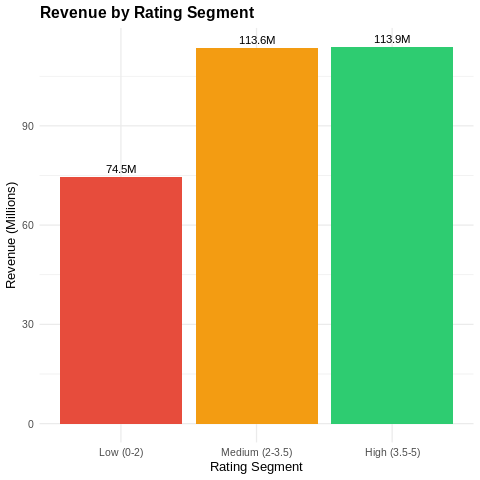

In [88]:
%%R
ggplot(seg_summary, aes(x=RatingSegment, y=Revenue/1e6,
                         fill=RatingSegment)) +
  geom_col(show.legend=FALSE) +
  geom_text(aes(label=sprintf('%.1fM', Revenue/1e6)),
            vjust=-0.5, size=4) +
  scale_fill_manual(values=c('#e74c3c','#f39c12','#2ecc71')) +
  labs(title='Revenue by Rating Segment',
       x='Rating Segment', y='Revenue (Millions)') +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'))

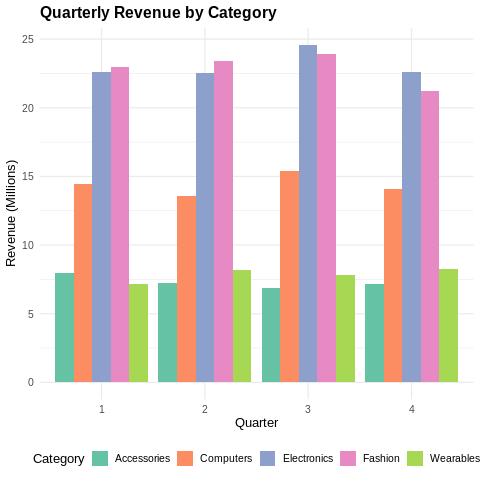

In [89]:
%%R
q_cat <- df %>%
  group_by(Quarter, Category) %>%
  summarise(Revenue=sum(TotalAmount)/1e6, .groups='drop')

ggplot(q_cat, aes(x=factor(Quarter), y=Revenue,
                   fill=Category)) +
  geom_col(position='dodge') +
  scale_fill_brewer(palette='Set2') +
  labs(title='Quarterly Revenue by Category',
       x='Quarter', y='Revenue (Millions)') +
  theme_minimal(base_size=13) +
  theme(plot.title=element_text(face='bold'),
        legend.position='bottom')